<a href="https://colab.research.google.com/github/SammyBoi242006/CCPS_project/blob/main/notebooks/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import zipfile, os

# datasets = [
#     {
#         'zip': '/content/drive/MyDrive/project/data/plantvillage_tomato.zip',
#         'extract': '/content/drive/MyDrive/project/data/plantvillage_tomato/'
#     },
#     {
#         'zip': '/content/drive/MyDrive/project/data/plantdoc_tomato.zip',
#         'extract': '/content/drive/MyDrive/project/data/plantdoc_tomato/'
#     }
# ]

# for d in datasets:
#     print(f"Extracting {d['zip']}...")
#     with zipfile.ZipFile(d['zip'], 'r') as zip_ref:
#         zip_ref.extractall(d['extract'])
#     print(f"Done! Contents: {os.listdir(d['extract'])}\n")

## Clone PlantDoc directly from GitHub
# !git clone https://github.com/pratikkayal/PlantDoc-Dataset \
#   /content/drive/MyDrive/project/data/plantdoc_tomato

# print("PlantDoc downloaded!")

fatal: destination path '/content/drive/MyDrive/project/data/plantdoc_tomato' already exists and is not an empty directory.
PlantDoc downloaded!


In [ ]:
BASE = '/content/drive/MyDrive/project'

# Fixed path — one level deeper
PLANTVILLAGE = '/content/drive/MyDrive/project/data/plantvillage_tomato/PlantVillage'
PLANTDOC = os.path.join(BASE, 'data/plantdoc_tomato')

print("Checking contents:")
print(os.listdir(PLANTVILLAGE))

Checking contents:
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

print("All imports done.")

All imports done.


In [ ]:
import os

# Check what's actually in your Drive
print("=== MyDrive contents ===")
print(os.listdir('/content/drive/MyDrive/project/data'))

=== MyDrive contents ===
['plantvillage_tomato.zip', 'plantdoc_tomato.zip', 'plantvillage_tomato', 'plantdoc_tomato']


In [ ]:
classes = os.listdir(PLANTVILLAGE)
class_counts = {}

for cls in sorted(classes):
    if not cls.startswith('Tomato'):  # skip Pepper and Potato for now
        continue
    cls_path = os.path.join(PLANTVILLAGE, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        class_counts[cls] = count
        print(f"{cls}: {count} images")

print(f"\nTotal classes: {len(class_counts)}")
print(f"Total images: {sum(class_counts.values())}")

Tomato_Bacterial_spot: 2127 images
Tomato_Early_blight: 1000 images
Tomato_Late_blight: 1909 images
Tomato_Leaf_Mold: 952 images
Tomato_Septoria_leaf_spot: 1771 images
Tomato_Spider_mites_Two_spotted_spider_mite: 1676 images
Tomato__Target_Spot: 1404 images
Tomato__Tomato_YellowLeaf__Curl_Virus: 3209 images
Tomato__Tomato_mosaic_virus: 373 images
Tomato_healthy: 1591 images

Total classes: 10
Total images: 16012


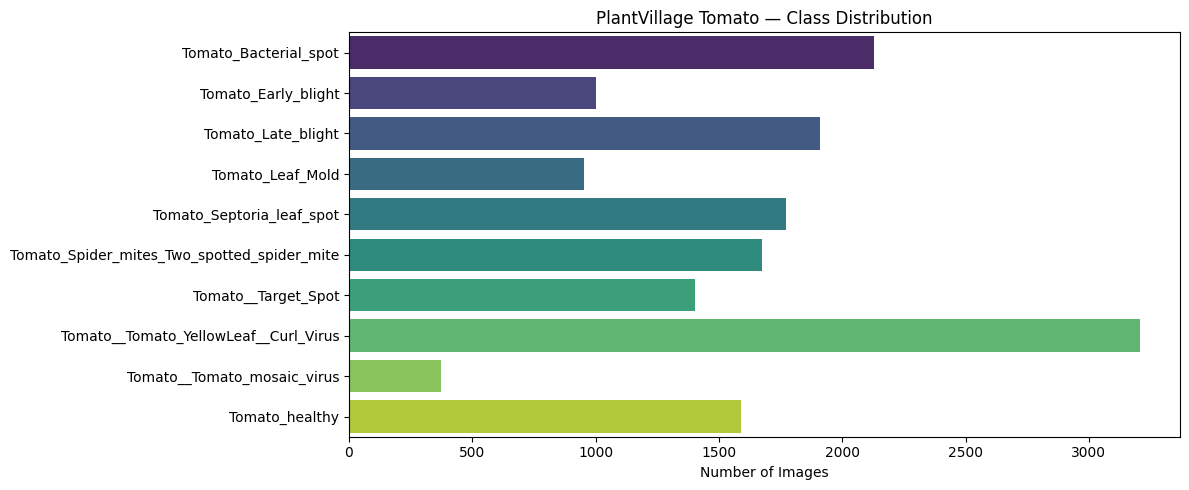

In [ ]:

# import os
# os.makedirs(os.path.join(BASE,"results"),exist_ok=True)


plt.figure(figsize=(12, 5))
sns.barplot(x=list(class_counts.values()), y=list(class_counts.keys()),
            hue=list(class_counts.keys()), palette='viridis', legend=False)
plt.title('PlantVillage Tomato — Class Distribution')
plt.xlabel('Number of Images')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'results/class_distribution.png'), dpi=150)
plt.show()

In [ ]:
sizes = []

for cls in class_counts:
    cls_path = os.path.join(PLANTVILLAGE, cls)
    for img_file in os.listdir(cls_path)[:20]:  # sample 20 per class
        img = Image.open(os.path.join(cls_path, img_file))
        sizes.append(img.size)

unique_sizes = Counter(sizes)
print("Unique image sizes found:")
for size, count in unique_sizes.most_common():
    print(f"  {size} — {count} images sampled")

Unique image sizes found:
  (256, 256) — 200 images sampled


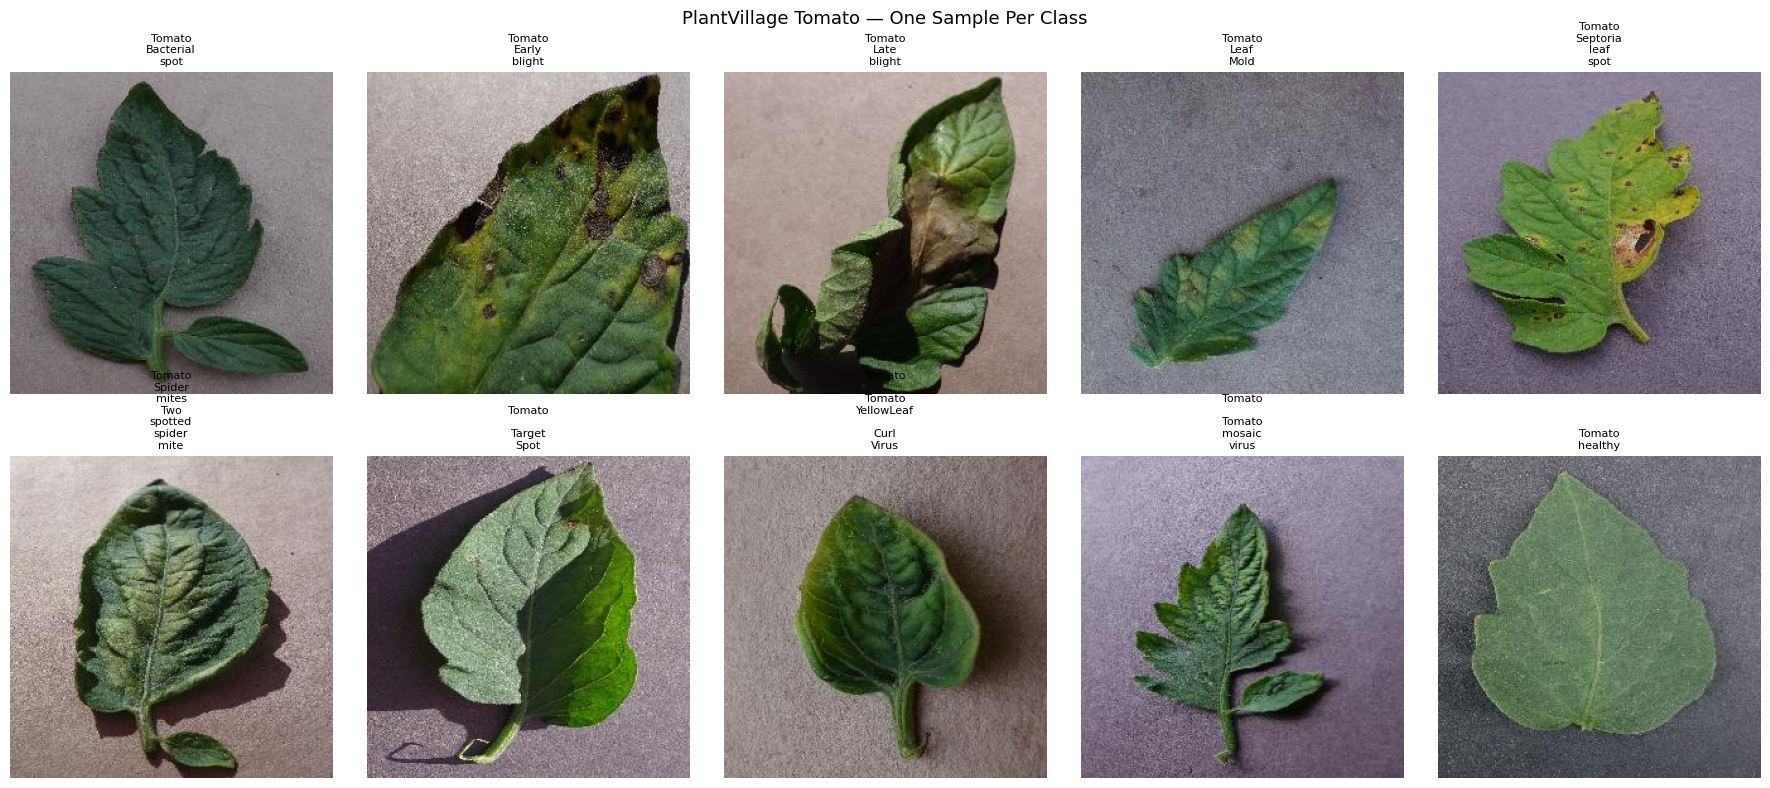

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, cls in enumerate(sorted(class_counts.keys())):
    cls_path = os.path.join(PLANTVILLAGE, cls)
    sample = os.path.join(cls_path, os.listdir(cls_path)[0])
    img = Image.open(sample)
    axes[i].imshow(img)
    axes[i].set_title(cls.replace('_', '\n'), fontsize=8)
    axes[i].axis('off')

plt.suptitle('PlantVillage Tomato — One Sample Per Class', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'results/sample_grid.png'), dpi=150)
plt.show()

In [ ]:
corrupt = []

for cls in class_counts:
    cls_path = os.path.join(PLANTVILLAGE, cls)
    for img_file in os.listdir(cls_path):
        try:
            img = Image.open(os.path.join(cls_path, img_file))
            img.verify()
        except Exception as e:
            corrupt.append((cls, img_file, str(e)))

print(f"Corrupt images found: {len(corrupt)}")
for c in corrupt:
    print(c)

Corrupt images found: 1
('Tomato__Tomato_YellowLeaf__Curl_Virus', 'svn-r6Yb5c', "cannot identify image file '/content/drive/MyDrive/project/data/plantvillage_tomato/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/svn-r6Yb5c'")


# EDA
**Dataset:** PlantVillage dataset ,selected only tomato images

##Fidnings
- Total classess: 10
- Total Images: 16,012
- Image size was almost 256x256 consistent
- corrupted images: only 1

## Class Distribution
| Class | Images |
|---|---|
| Tomato_Bacterial_spot | 2127 |
| Tomato_Early_blight | 1000 |
| Tomato_Late_blight | 1909 |
| Tomato_Leaf_Mold | 952 |
| Tomato_Septoria_leaf_spot | 1771 |
| Tomato_Spider_mites | 1676 |
| Tomato_Target_Spot | 1404 |
| Tomato_YellowLeaf_Curl_Virus | 3209 |
| Tomato_mosaic_virus | 373 |
| Tomato_healthy | 1591 |

##comments
There is some imbalance in the images where yellow Curl has 3000+ images while mosaic one has only about 400.
This will be encounteres during the model training.

